# 04 — Knowledge Graph Construction & Drug Target Discovery

**Pipeline Step 4 of 5**

Constructs a **Micro-Clinical Knowledge Graph (Micro-CKG)** from the AD spatial transcriptomics data and enriches it with external biological knowledge.

### Pipeline
1. **Leiden clustering** of spots → proxy cell-type assignments
2. **Wilcoxon DE testing** across clusters → DE-filtered edges (p_adj < 0.05, |log2FC| > 0.5)
3. **Build BioCypher graph** with Gene, CellType, and Region nodes
4. **Spatial validation** via Moran's I autocorrelation
5. **Translational discovery** — mouse→human orthologs, GO enrichment, ChEMBL drug targets

### Inputs
| File | Description |
|---|---|
| `data/processed/ad_preprocessed.h5ad` | QC-filtered, normalized AnnData from Step 01 |
| `cache/stabl_results_<hash>.pkl` | Stabl results from Step 02 |
| `config/schema_config.yaml` | BioCypher schema mapping |

### Outputs
| File | Description |
|---|---|
| `cache/micro_ckg.graphml` | Serialized Micro-CKG in GraphML format |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.spatial_pipeline import (
    load_adata, run_stabl_cached, compute_clusters,
    annotate_clusters, assign_condition_labels,
)
from src.biocypher_adapter import build_micro_ckg, save_graph, visualize_graph
from src.spatial_analytics import (
    compute_spatial_neighbors, compute_spatial_autocorr,
    run_nhood_enrichment,
)
from src.external_knowledge import (
    map_orthologs, run_go_enrichment, get_drug_targets,
)
from src.graph_analytics import (
    detect_communities, compute_centrality, find_bridge_genes, summarise_graph,
)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
CACHE_DIR = PROJECT_ROOT / "cache"

print("Imports ready.")

/Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports ready.


## 4.1 Load Data and Stabl Results

In [2]:
adata = load_adata(DATA_PROCESSED / "ad_preprocessed.h5ad")

stabl_result = run_stabl_cached(
    adata,
    cache_dir=CACHE_DIR,
    dataset_name="geo_ad",
    label_method="condition",
    n_bootstraps=50,
    prefilter="hvg",
    n_hvgs=2000,
)

print(f"\n{stabl_result['n_selected']} Stabl-selected features loaded.")

  Loading dataset: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/data/processed/ad_preprocessed.h5ad
  Shape: 15687 spots × 22265 genes
  Loading cached Stabl results: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/stabl_results_8e7086389baf.pkl

22 Stabl-selected features loaded.


## 4.2 Compute Leiden Clusters

Before building the graph, we need cell-type assignments. We apply Leiden community detection (a graph-based clustering algorithm) to the spot-level expression profiles. The procedure is: select highly variable genes, compute PCA (40 components), build a k-nearest-neighbor graph (k=10), and partition the graph using the Leiden algorithm at resolution 0.8.

Each resulting cluster represents a group of spots with similar expression profiles. These clusters serve as proxy cell-type labels (e.g., neuronal subtypes, glial populations) and are used to create CellType nodes in the knowledge graph. The cluster-to-region mapping assigns anatomical labels (Cortex, Hippocampus, Thalamus, etc.) based on cluster rank order, providing spatial context for each cell-type node.

In [3]:
adata = compute_clusters(adata, n_hvgs=2000)
print(f"\nLeiden clusters: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts().sort_index())

# Annotate clusters with brain-region marker gene signatures
cluster_annotation = annotate_clusters(adata)
print("\nCluster annotations:")
for cid, region in sorted(cluster_annotation.items(), key=lambda x: int(x[0])):
    print(f"  Cluster {cid} → {region}")

# Assign condition labels based on ground-truth metadata
condition_labels = assign_condition_labels(adata)
n_ad = int(condition_labels.sum())
n_wt = len(condition_labels) - n_ad
print(f"\nCondition labels: {n_ad} AD / {n_wt} WT spots")

  Selected 2000 highly variable genes (requested 2000)


/Users/shaunfchen/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


  Leiden clustering: 18 clusters

Leiden clusters: 18
leiden
0      642
1     1447
2     1272
3      867
4      940
5     2145
6      436
7      700
8     1458
9     1472
10     483
11     449
12     538
13    1015
14    1142
15     145
16     341
17     195
Name: count, dtype: int64
  Cluster annotation: {'White_Matter': np.int64(11), 'Cortex': np.int64(3), 'Cerebellum': np.int64(2), 'Thalamus': np.int64(1), 'Hippocampus': np.int64(1)}

Cluster annotations:
  Cluster 0 → Cortex
  Cluster 1 → White_Matter
  Cluster 2 → Cortex
  Cluster 3 → Cortex
  Cluster 4 → Cerebellum
  Cluster 5 → Thalamus
  Cluster 6 → White_Matter
  Cluster 7 → White_Matter
  Cluster 8 → White_Matter
  Cluster 9 → White_Matter
  Cluster 10 → White_Matter
  Cluster 11 → White_Matter
  Cluster 12 → White_Matter
  Cluster 13 → Hippocampus
  Cluster 14 → White_Matter
  Cluster 15 → White_Matter
  Cluster 16 → Cerebellum
  Cluster 17 → White_Matter
  Neuroinflammation scoring (12 markers): 7844 reactive / 7843 homeost

## 4.3 Build Micro-CKG (DE-Filtered, Gene-Expanded)

The knowledge graph uses **Wilcoxon rank-sum differential expression testing** to create statistically significant edges instead of simple expression thresholds.

**Gene expansion:** Stabl's strict FDP+ threshold often selects very few genes (e.g., 2). To ensure the graph is informative for drug discovery, `build_micro_ckg` automatically expands the gene list to at least `min_genes` (default 20) by including the next-highest-ranked genes by stability score. The original Stabl-selected genes are marked `is_selected=True`; expanded genes are marked `is_selected=False`.

**Filtering criteria:**
- Gene → CellType edges require adjusted p-value < 0.05 AND |log2FC| > 0.5
- Gene → Region edges are aggregated from DE-significant cluster-level associations

**Edge attributes include:**
- `log2fc` — log2 fold change from DE test
- `pval_adj` — Benjamini-Hochberg adjusted p-value
- `stability_score` — Stabl bootstrap stability score
- `mean_expression` — mean expression in the cluster

In [4]:
schema_path = PROJECT_ROOT / "config" / "schema_config.yaml"

graph = build_micro_ckg(
    stabl_result=stabl_result,
    adata=adata,
    schema_path=schema_path,
    cluster_annotation=cluster_annotation,
    min_genes=20,
)

print(f"\nMicro-CKG:")
print(f"  Nodes: {graph.number_of_nodes()}")
print(f"  Edges: {graph.number_of_edges()}")

# Quick topology summary
summary = summarise_graph(graph)
print(f"  Density: {summary['density']:.4f}")
print(f"  Components: {summary['n_components']}")

  Running DE testing (Wilcoxon rank-sum)...
  DE results: 396 tests, 346 significant
  Building Micro-CKG...
  Micro-CKG: 45 nodes (22 genes, 18 cell types, 5 regions)
  Micro-CKG: 471 edges (DE-filtered)

Micro-CKG:
  Nodes: 45
  Edges: 471
  Graph summary: 45 nodes, 471 edges, density=0.2379, 1 components
  Density: 0.2379
  Components: 1


## 4.4 Graph Analytics & Drug Discovery Dashboard

Multi-panel visualization showing:
- **Top hub genes** — the most connected biomarkers and their cell-type/region associations
- **Gene × Region heatmap** — which biomarkers are spatially specific to which brain regions
- **Centrality ranking** — PageRank identifies the most influential genes in the network
- **Edge composition** — breakdown of relationship types in the knowledge graph

  Communities: 3 detected via Louvain
  Centrality computed for 45 nodes
  Communities: 3 detected via Louvain
  Bridge genes: 22/22 genes bridge >1 community
Top 10 hub genes by PageRank:
              degree  betweenness  pagerank
gene:Nptxr        21     0.011864  0.010974
gene:Prnp         21     0.011896  0.010974
gene:Calb1        20     0.010417  0.010974
gene:Ncdn         18     0.008225  0.010974
gene:Tmem88b      19     0.009038  0.010974
gene:Tsc22d4      21     0.011997  0.010974
gene:Adipor2      20     0.010422  0.010974
gene:Prkcg        22     0.013373  0.010974
gene:Polr3e       16     0.006477  0.010974
gene:Necab2       23     0.014691  0.010974

Bridge genes (connect multiple graph communities):
              gene  bridge_score  n_communities_bridged  betweenness
       gene:Necab2      0.020367                      3     0.014691
          gene:Cck      0.020367                      3     0.014691
        gene:Prkcg      0.018539                      3     0.013373

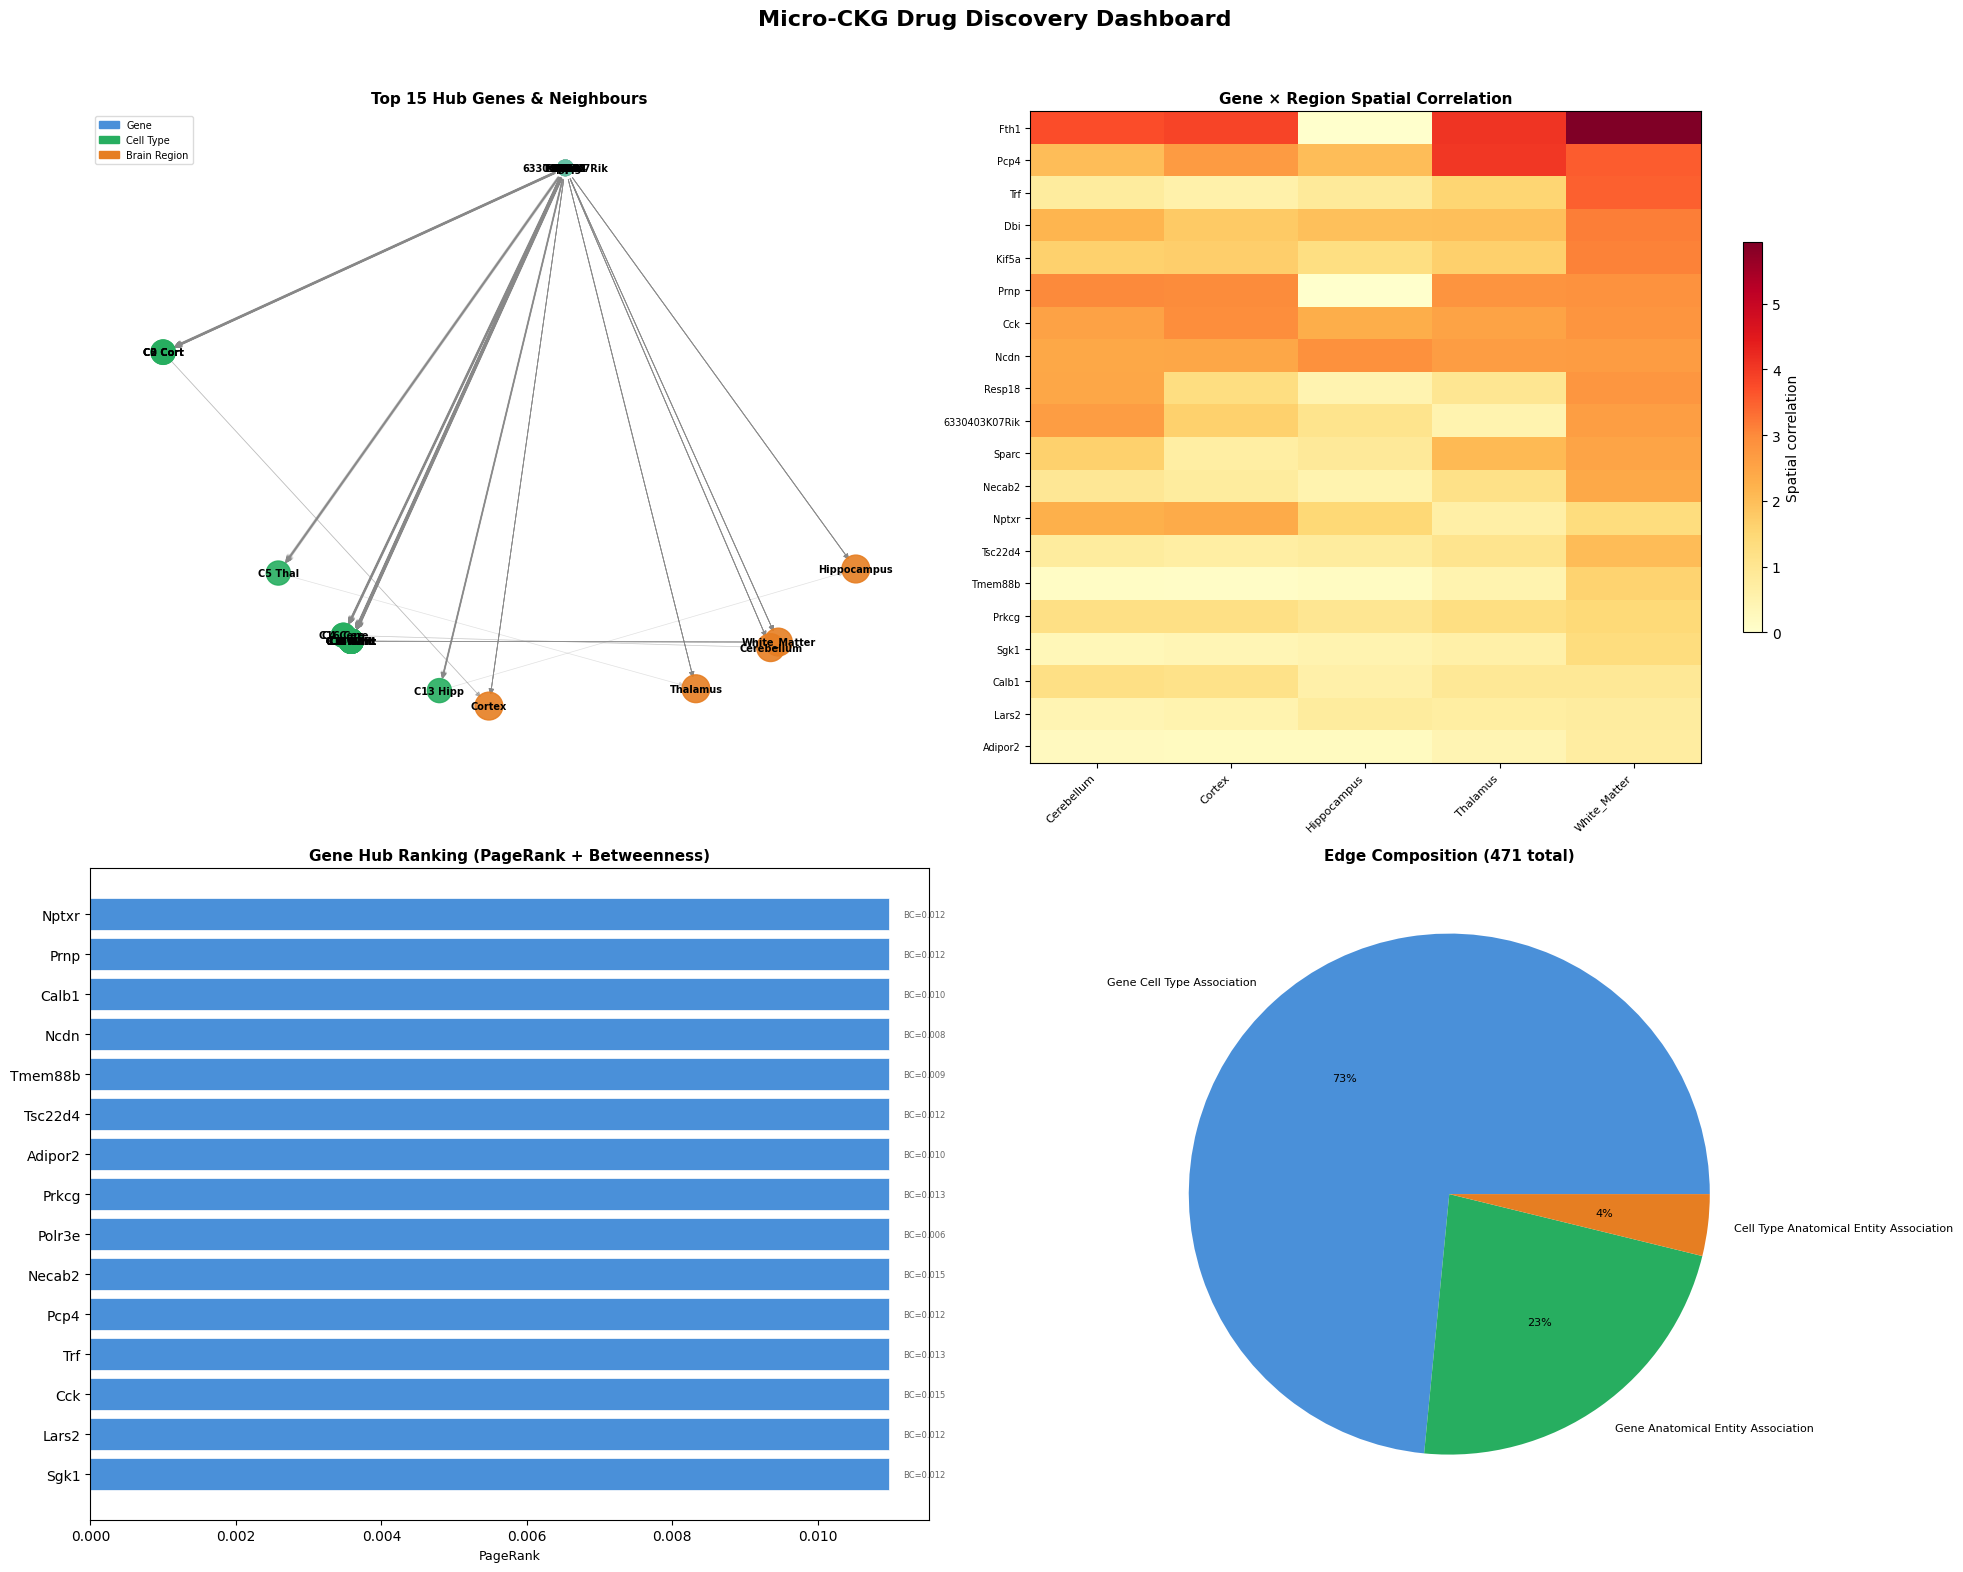

In [5]:
# Community detection & centrality
community_map = detect_communities(graph)
centrality_df = compute_centrality(graph)
bridge_df = find_bridge_genes(graph, centrality_df)

print("Top 10 hub genes by PageRank:")
gene_centrality = centrality_df[centrality_df["label"] == "gene"].head(10)
print(gene_centrality[["degree", "betweenness", "pagerank"]].to_string())

print("\nBridge genes (connect multiple graph communities):")
print(bridge_df.head(10)[["gene", "bridge_score", "n_communities_bridged", "betweenness"]].to_string(index=False))

# Multi-panel drug discovery dashboard
visualize_graph(graph, community_map=community_map, centrality_df=centrality_df)

## 4.5 Save Graph

The Micro-CKG is serialized to GraphML format, a standard XML-based graph format supported by NetworkX, Cytoscape, Neo4j, and other graph analysis tools. This file serves as the input to the LLM agent in Step 05 and can also be loaded into graph visualization software for interactive exploration.

In [6]:
graph_path = save_graph(graph, CACHE_DIR / "micro_ckg.graphml")
print(f"\nGraph persisted: {graph_path}")
print(f"File size: {graph_path.stat().st_size / 1e3:.1f} KB")

  Graph saved to /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml

Graph persisted: /Users/shaunfchen/Documents/Repositories/spatial-microckg-agent/cache/micro_ckg.graphml
File size: 159.5 KB


## 4.6 Spatial Validation (Moran's I)

**Why this matters for drug development:** A biomarker is only therapeutically relevant if its spatial expression pattern is non-random. Moran's I > 0 with p < 0.05 confirms that a gene shows **spatially clustered expression** — it marks a real tissue compartment, not noise. This spatial specificity is critical for targeted drug delivery.

In [7]:
# Build spatial neighbourhood graph
adata = compute_spatial_neighbors(adata, n_neighs=6)

# Spatial autocorrelation — test Stabl-selected genes
moran_df = compute_spatial_autocorr(
    adata,
    genes=stabl_result["selected_genes"],
    mode="moran",
    n_perms=100,
)

# Show top spatially autocorrelated genes
sig_moran = moran_df[moran_df["pval_norm"] < 0.05].sort_values("I", ascending=False)
print(f"\nTop spatially autocorrelated Stabl genes (Moran's I):")
print(f"({len(sig_moran)}/{len(stabl_result['selected_genes'])} genes spatially significant)\n")
print(sig_moran.head(15)[["I", "pval_norm"]].to_string())

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
  Spatial neighbours computed (n_neighs=6)


100%|██████████| 100/100 [00:05<00:00, 19.16/s]


  Spatial autocorrelation (moran): 22/22 genes significant (p < 0.05)

Top spatially autocorrelated Stabl genes (Moran's I):
(22/22 genes spatially significant)

                      I  pval_norm
Sparc          0.631413        0.0
Nptxr          0.539816        0.0
Cck            0.497348        0.0
Fth1           0.398287        0.0
Trf            0.385880        0.0
Resp18         0.383264        0.0
Pcp4           0.370316        0.0
Calb1          0.316180        0.0
6330403K07Rik  0.313826        0.0
Prkcg          0.307736        0.0
Dbi            0.300790        0.0
Necab2         0.296341        0.0
Tmem88b        0.256181        0.0
Ncdn           0.254490        0.0
Kif5a          0.243841        0.0


## 4.7 Translational Drug Target Discovery

This is the key drug-development step. We take the spatially-validated mouse biomarker genes and:
1. **Map to human orthologs** — mouse gene symbols → human equivalents via HomoloGene
2. **Pathway enrichment** — what GO biological processes / KEGG pathways do these genes converge on?
3. **Drug target query** — which human orthologs have approved or clinical-stage drugs in ChEMBL?

This creates a direct pipeline from spatial transcriptomics → druggable targets.

In [8]:
# Mouse → Human ortholog mapping
ortho_df = map_orthologs(stabl_result["selected_genes"])
human_genes = ortho_df["human_symbol"].dropna().tolist()
print(f"Mapped {len(human_genes)} / {len(stabl_result['selected_genes'])} genes to human orthologs")
display(ortho_df.head(10))

# GO / KEGG pathway enrichment
enrich_df = run_go_enrichment(human_genes)
if enrich_df is not None and not enrich_df.empty:
    print(f"\nTop enriched pathways ({len(enrich_df)} total):")
    display(enrich_df.head(15))
else:
    print("\nNo significant enrichment results returned.")

# ChEMBL drug target lookup
drug_df = get_drug_targets(human_genes)
if drug_df is not None and not drug_df.empty:
    print(f"\nDruggable targets found: {drug_df['gene'].nunique()} genes, {len(drug_df)} drug associations")
    display(drug_df.head(15))
else:
    print("\nNo drug targets found in ChEMBL for these genes.")

  Orthologs loaded from cache (21 mappings)
Mapped 21 / 22 genes to human orthologs


,mouse_symbol,human_symbol,human_entrezgene,ensembl_gene
0,Ncdn,NCDN,23154,ENSG00000020129
1,Cdc42ep1,CDC42EP1,11135,ENSG00000128283
2,Sparc,SPARC,6678,ENSG00000113140
3,Calb1,CALB1,793,ENSG00000104327
4,Pcp4,PCP4,5121,ENSG00000183036
5,Nptxr,NPTXR,23467,ENSG00000221890
6,Dbi,DBI,1622,ENSG00000155368
7,Kif5a,KIF5A,3798,ENSG00000155980
8,Adipor2,ADIPOR2,79602,ENSG00000285070
9,Fth1,FTH1,2495,ENSG00000167996


  GO enrichment loaded from cache

Top enriched pathways (433 total):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Gene_set_library
0,GO_Biological_Process_2023,Long-Term Memory (GO:0007616),3/20,0.000001,0.000221,0,0,195.705882,2680.858518,PRNP;CALB1;SGK1,GO_Biological_Process_2023
1,GO_Biological_Process_2023,Regulation Of Glutamate Receptor Signaling Pat...,2/5,0.000010,0.001032,0,0,700.912281,8036.694420,NECAB2;PRNP,GO_Biological_Process_2023
2,GO_Biological_Process_2023,Memory (GO:0007613),3/58,0.000030,0.001948,0,0,60.375758,629.460919,PRNP;CALB1;SGK1,GO_Biological_Process_2023
3,GO_Biological_Process_2023,Positive Regulation Of Protein Localization To...,2/79,0.003081,0.065925,0,0,27.207109,157.322012,NECAB2;PRNP,GO_Biological_Process_2023
4,GO_Biological_Process_2023,Adiponectin-Activated Signaling Pathway (GO:00...,1/5,0.005239,0.065925,0,0,249.687500,1311.244059,ADIPOR2,GO_Biological_Process_2023
5,GO_Biological_Process_2023,Regulation Of Neuron Apoptotic Process (GO:004...,2/105,0.005372,0.065925,0,0,20.312724,106.166470,PRKCG;PRNP,GO_Biological_Process_2023
6,GO_Biological_Process_2023,Regulation Of Digestive System Process (GO:004...,1/6,0.006284,0.065925,0,0,199.740000,1012.625496,SGK1,GO_Biological_Process_2023
7,GO_Biological_Process_2023,Anterograde Dendritic Transport (GO:0098937),1/6,0.006284,0.065925,0,0,199.740000,1012.625496,KIF5A,GO_Biological_Process_2023
8,GO_Biological_Process_2023,Dense Core Granule Cytoskeletal Transport (GO:...,1/6,0.006284,0.065925,0,0,199.740000,1012.625496,KIF5A,GO_Biological_Process_2023
9,GO_Biological_Process_2023,Regulation Of Anion Channel Activity (GO:0010359),1/6,0.006284,0.065925,0,0,199.740000,1012.625496,PRNP,GO_Biological_Process_2023


  Drug targets loaded from cache (12 entries)

Druggable targets found: 2 genes, 12 drug associations


,gene,drug_name,mechanism_of_action,max_phase
0,TF,INFLIXIMAB,TNF-alpha inhibitor,4.0
1,TF,CERTOLIZUMAB PEGOL,TNF-alpha inhibitor,4.0
2,TF,ADALIMUMAB,TNF-alpha inhibitor,4.0
3,TF,ETANERCEPT,TNF-alpha inhibitor,4.0
4,TF,GOLIMUMAB,TNF-alpha inhibitor,4.0
5,CCK,CERULETIDE DIETHYLAMINE,Cholecystokinin A receptor agonist,4.0
6,CCK,CE-326597,Cholecystokinin A receptor agonist,2.0
7,CCK,DEXLOXIGLUMIDE,Cholecystokinin A receptor antagonist,3.0
8,CCK,SINCALIDE,Cholecystokinin A receptor agonist,4.0
9,CCK,CI-988,Cholecystokinin B receptor antagonist,1.0
